In [43]:
# Here we will analyse highest paying skills and highest demanding skills, and plot them on chart

# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

# Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Sorting the Dataframe
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# converting job_skills from string to list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [44]:
# Now lets create a new dataframe where job_title_short is Data Engineer and job_country is United States, and remove blank rows
df_US = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'United States')].copy().dropna(subset='salary_year_avg')

# exploding the job_skills 
df_US = df_US.explode('job_skills')

In [45]:
# now lets print for job skills and salary_year_avg
df_US[['salary_year_avg','job_skills']].head(5)

,salary_year_avg,job_skills
92,120000.0,sql
92,120000.0,python
146,129500.0,golang
146,129500.0,scala
146,129500.0,python


In [46]:
df_US_pay = df_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median',ascending=False).head(10)

In [47]:
df_US_skill = df_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False).head(10)

In [48]:
print(df_US_pay)
print(df_US_skill)

            count    median
job_skills                 
mongo          78  208114.0
vue             1  200000.0
solidity        1  192500.0
node           24  190000.0
ggplot2         2  176250.0
macos           2  172000.0
clojure         2  170866.5
atlassian      18  169860.0
rust            7  165000.0
opencv          1  162500.0
            count        median
job_skills                     
sql          2110  125000.00000
python       2007  127794.50000
aws          1313  131000.00000
spark         968  137410.15625
azure         961  125000.00000
snowflake     765  130700.00000
java          732  137000.00000
kafka         536  145000.00000
nosql         519  140000.00000
redshift      514  135000.00000


[]

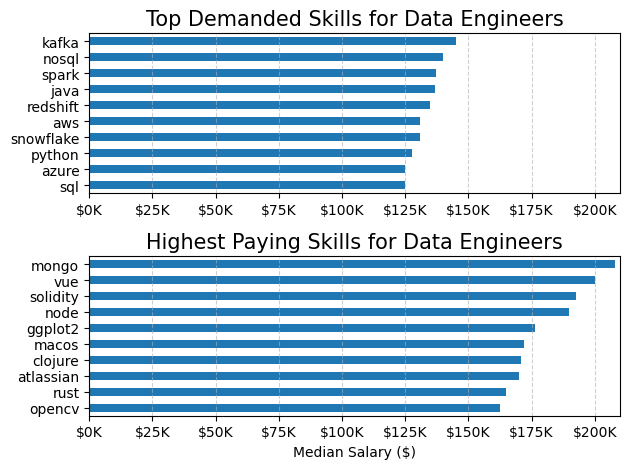

In [49]:
# now lets plot subplots for the graph
from tkinter.font import BOLD

import matplotlib.ticker as mticker

fig, ax = plt.subplots(2,1)

# plot 1 
df_US_skill.sort_values(by='median',ascending=True).plot(kind='barh', y='median',ax=ax[0], legend=False)

# formatting
ax[0].set_title('Top Demanded Skills for Data Engineers',fontsize=15)
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_xlim(0,210000)
ax[0].grid(axis='x', linestyle='--', alpha=0.6)
ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))

# plot 2
df_US_pay.sort_values(by='median',ascending=True).plot(kind='barh', y='median',ax=ax[1], legend=False)

# formatting
ax[1].set_title('Highest Paying Skills for Data Engineers',fontsize=15)
ax[1].set_xlabel('Median Salary ($)')
ax[1].set_ylabel('')
ax[1].set_xlim(0,210000)
ax[1].grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.plot()
